In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import percentileofscore

In [2]:
savefig = True

water_year_start, water_year_end = ("2022-04-01", "2023-03-31")
twenty_years_start, twenty_years_end = ("2002-04-01", "2022-03-31")


datapath = Path("../data/unscaled_flow.csv")
figpath =  Path("../results")

rivers = ['Yelcho', 'Puelo', 'Palena', 'Cisnes', 'Aysen']

In [3]:
flow_data = pd.read_csv(datapath).set_index("Date")
flow_data.index = pd.to_datetime(flow_data.index)

In [4]:
fd20 = flow_data[twenty_years_start:twenty_years_end]
fd1 = flow_data[water_year_start:water_year_end]

In [5]:
water_years = pd.Series(2003, index=fd20.index)
year=2003
apr1date = pd.Timestamp(year=year, month=4, day=1)
while fd20.index[-1] >= apr1date:
    year += 1
    apr1date = pd.Timestamp(year=year, month=4, day=1)
    water_years += (fd20.index >= apr1date)

In [6]:
percentile = lambda a, b: (a >= b).mean()

In [7]:
fd20_gb = fd20.groupby(water_years)

# Red text (annual flow percentiles)
print("I think this is the stuff described in the red text")
pd.DataFrame(
    [
        percentile(fd1.sum(), fd20_gb.sum()),
        percentile(fd1.max(), fd20_gb.max()),
        percentile(fd1.min(), fd20_gb.min())
    ],
    index=["Annual", "Maxes", "Mins"]
).transpose()

I think this is the stuff described in the red text


,Annual,Maxes,Mins
Aysen,0.210526,0.736842,0.578947
Cisnes,0.578947,0.631579,0.789474
Palena,0.210526,0.263158,0.368421
Puelo,0.315789,0.052632,0.526316
Yelcho,0.368421,0.157895,0.736842


In [8]:
quantiles20y = fd20.quantile([0.1, 0.5, 0.9])
print("10th percentile, 50th percentile, 90th percentile")
pd.DataFrame(
    quantiles20y.transpose().apply(lambda qt: (fd1 <= qt).mean()),
    #columns=quantiles.index.astype("str")+"th"
)

10th percentile, 50th percentile, 90th percentile


,0.1,0.5,0.9
Aysen,0.197260,0.684932,0.939726
Cisnes,0.049315,0.443836,0.909589
Palena,0.186301,0.572603,0.917808
Puelo,0.128767,0.490411,0.945205
Yelcho,0.071233,0.504110,0.953425


In [9]:
quantiles20y.loc[0.9]

Aysen      879.0
Cisnes     392.0
Palena    1407.6
Puelo     1112.6
Yelcho     623.0
Name: 0.9, dtype: float64

In [10]:
# Count number of "floods (80%ile and 5 days)"
days_cutoff = 5
above80th = (fd1 >= quantiles20y.quantile(0.8))
#(above90th > above90th.shift(1, fill_value=False)).sum()
floods_filtered = pd.concat(
    [pd.DataFrame(data=False, index=[0], columns=above80th.columns), above80th] # for ffill
).replace({True: pd.NA}).ffill(limit=days_cutoff).fillna(True)
floods_filtered = floods_filtered.replace({False: pd.NA}).bfill(limit=days_cutoff).fillna(False) # Restore the last 5 days
floods_filtered = floods_filtered.iloc[1:] # get rid of that row from 2 lines ago
(floods_filtered > floods_filtered.shift(1, fill_value=False)).sum()

C:\Users\foxni\AppData\Local\Temp\ipykernel_46216\750575970.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({True: pd.NA}).ffill(limit=days_cutoff).fillna(True)
C:\Users\foxni\AppData\Local\Temp\ipykernel_46216\750575970.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  floods_filtered = floods_filtered.replace({False: pd.NA}).bfill(limit=days_cutoff).fillna(False) # Restore the last 5 days


Aysen     1
Cisnes    2
Palena    2
Puelo     3
Yelcho    3
dtype: int64

In [11]:
# Count number of "droughts"
below10th = (fd1 >= quantiles20y.loc[0.9])
#(above90th > above90th.shift(1, fill_value=False)).sum()
droughts_filtered = pd.concat(
    [pd.DataFrame(data=False, index=[0], columns=below10th.columns), below10th]
).replace({True: pd.NA}).ffill(limit=13).fillna(True)
(droughts_filtered > droughts_filtered.shift(1, fill_value=False)).sum()

C:\Users\foxni\AppData\Local\Temp\ipykernel_46216\3389163688.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({True: pd.NA}).ffill(limit=13).fillna(True)


Aysen     0
Cisnes    0
Palena    0
Puelo     0
Yelcho    0
dtype: int64

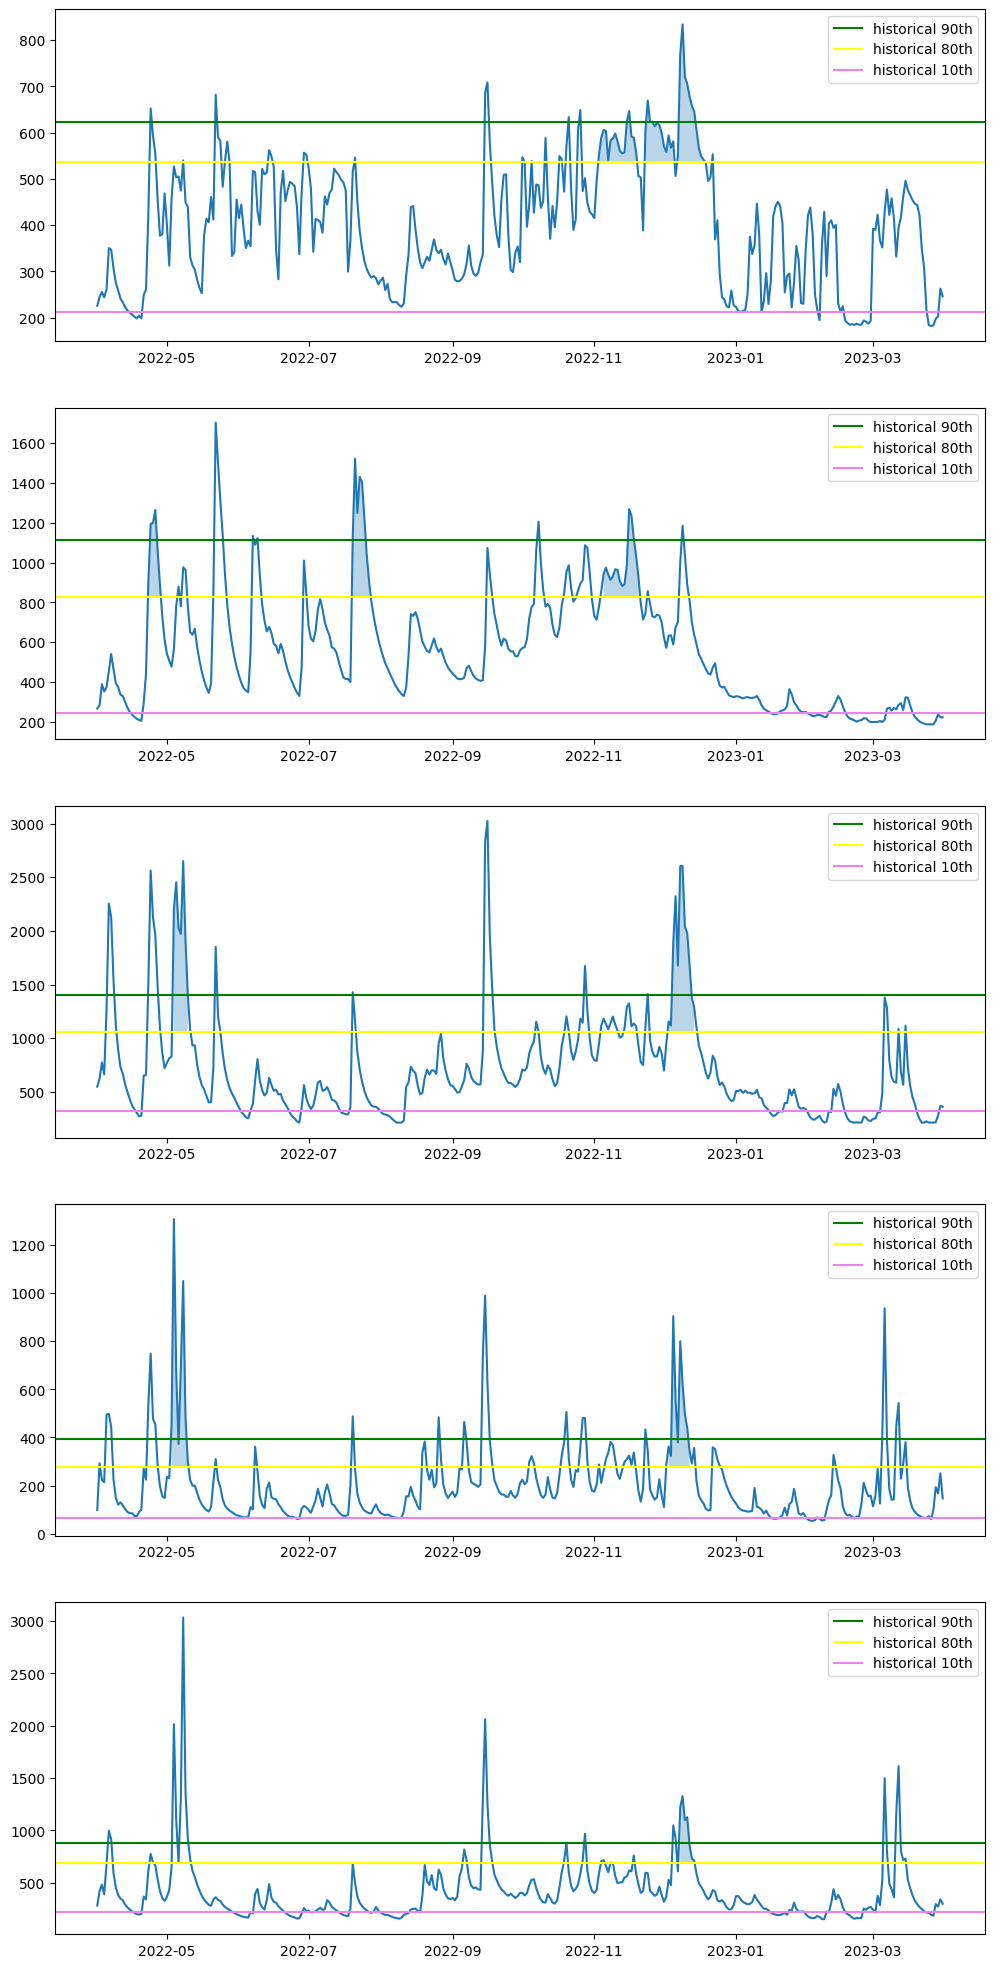

In [12]:
fig, axes = plt.subplots(figsize=(12, 5*len(rivers)), nrows=len(rivers))

for riv, ax in zip(rivers, axes):
    ax.plot(fd1[riv])
    ax.axhline(fd20[riv].quantile(0.9), color="green", label="historical 90th")
    ax.axhline(fd20[riv].quantile(0.8), color="yellow", label="historical 80th")
    ax.axhline(fd20[riv].quantile(0.1), color="violet", label="historical 10th")
    floodvals = fd1[riv].where(floods_filtered[riv], other=pd.NA)
    ax.fill_between(x=floodvals.index, y1=floodvals, y2=fd20[riv].quantile(0.8), alpha=0.3)
    ax.legend()

In [13]:
(floods_filtered > floods_filtered.shift(1, fill_value=False)).iloc[1:]

,Aysen,Cisnes,Palena,Puelo,Yelcho
2022-04-02 00:00:00,False,False,False,False,False
2022-04-03 00:00:00,False,False,False,False,False
2022-04-04 00:00:00,False,False,False,False,False
2022-04-05 00:00:00,False,False,False,False,False
2022-04-06 00:00:00,False,False,False,False,False
...,...,...,...,...,...
2023-03-27 00:00:00,False,False,False,False,False
2023-03-28 00:00:00,False,False,False,False,False
2023-03-29 00:00:00,False,False,False,False,False
2023-03-30 00:00:00,False,False,False,False,False


In [14]:
fd1_qs = pd.DataFrame(
    data=[percentileofscore(fd20[riv], fd1[riv]) for riv in fd1.columns],
    index=fd1.columns
).transpose()

# Mean 20y percentiles
fd1_qs.agg(["mean", "median"]) # No mode

C:\Users\foxni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,Aysen,Cisnes,Palena,Puelo,Yelcho
mean,38.170853,52.901372,44.692733,48.620855,NaN
median,31.923340,54.182067,41.765914,53.004791,NaN


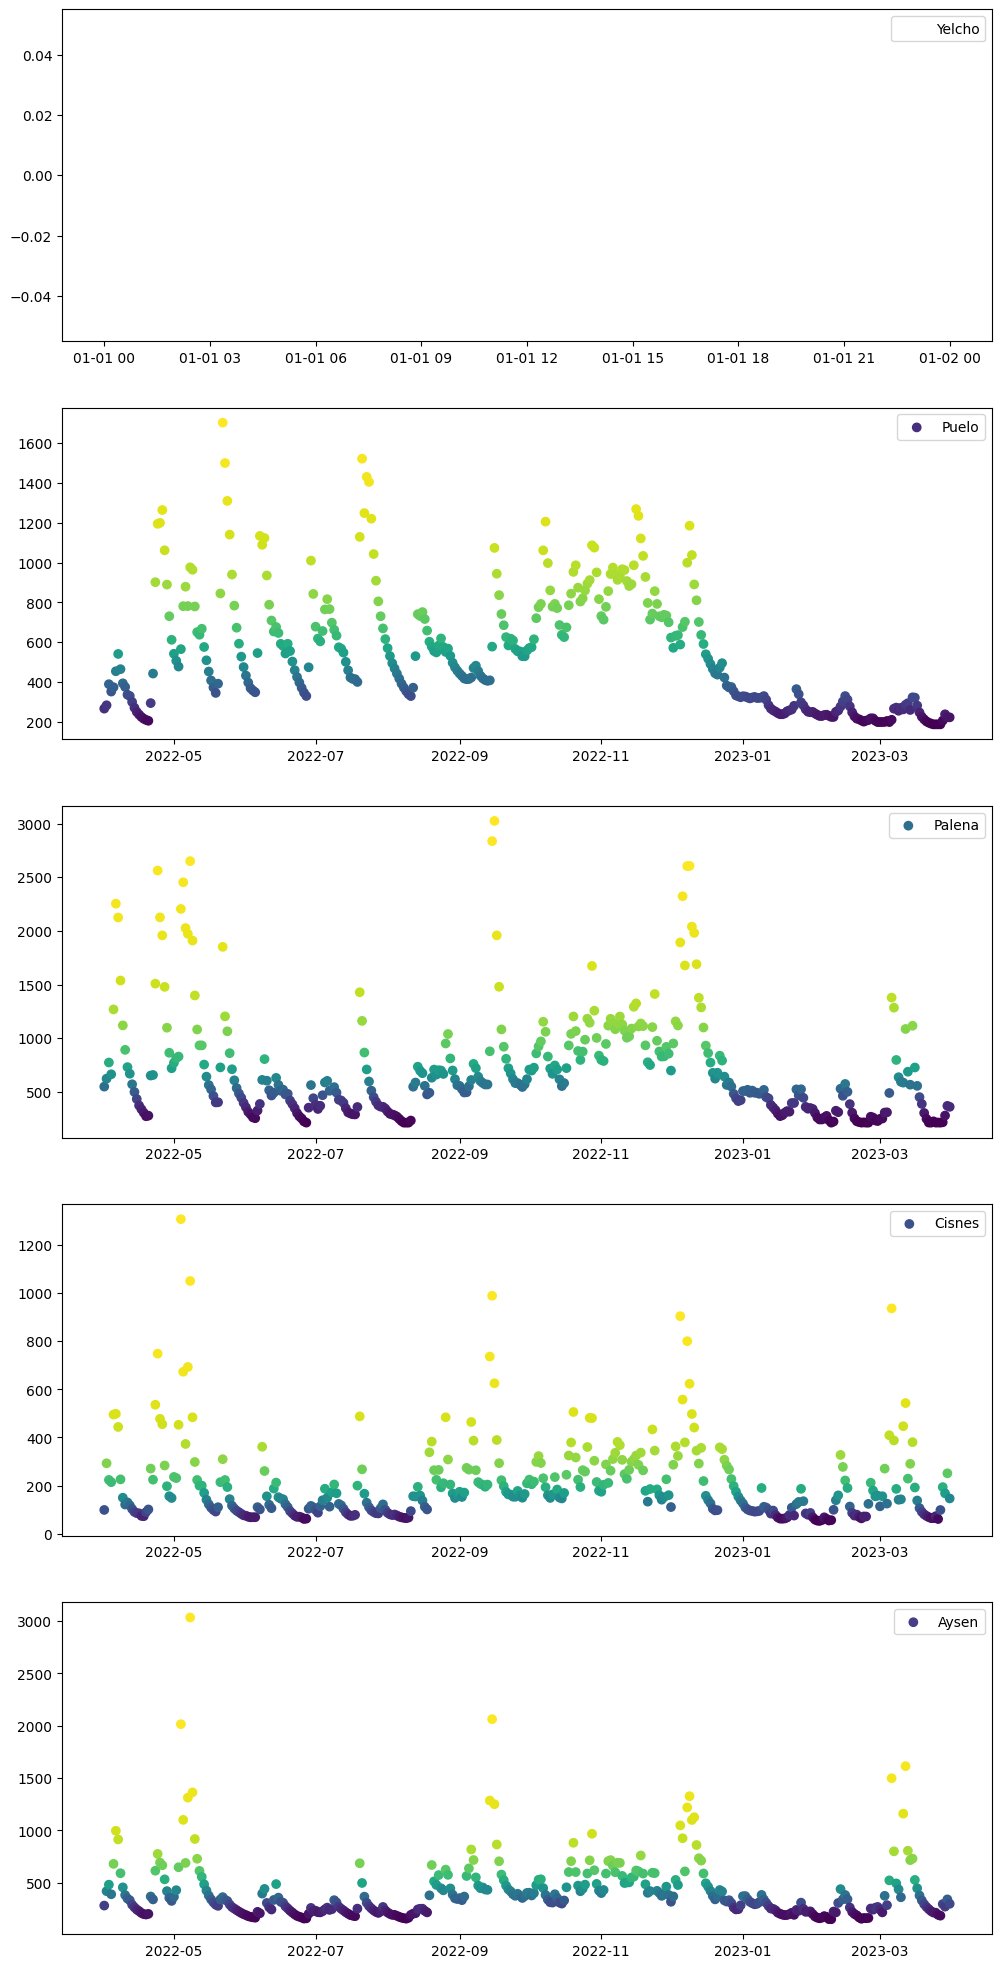

In [15]:
fig, axes = plt.subplots(figsize=(12, 5*len(rivers)), nrows=len(rivers))

for riv, ax in zip(rivers, axes):
    # sns.lineplot(
    #     data=fd1,
    #     x=fd1.index,
    #     y=riv,
    #     hue=fd1_qs[riv],
    #     palette="viridis",
    #     ax=ax
    # )
    ax.scatter(
        fd1.index,
        fd1[riv],
        c=fd1_qs[riv],
        cmap="viridis",
        label=riv
    )
    ax.legend()

In [16]:
fd20.mean()

Aysen     513.543614
Cisnes    200.569135
Palena    792.945705
Puelo     624.625082
Yelcho    425.873396
dtype: float64

In [17]:
flow_data.mean() # ALLL data. Please specify a date in 2002

Aysen     512.579314
Cisnes    204.432693
Palena    797.794132
Puelo     606.629613
Yelcho    428.038753
dtype: float64

In [56]:
pd.to_datetime("2024-02-29").dayofyear

60

In [91]:
def remove_feb29(df, merge=False):
    feb29s = (df.index.month == 2) & (df.index.day == 29)
    dayofyear = df.index.dayofyear
    dayofyear -= df.index.dayofyear > 60
    if not merge:
        dayofyear *= ~feb29s
    df = df[dayofyear != 0]
    dayofyear = dayofyear[dayofyear != 0]
    return df, dayofyear

In [134]:
fd20_filtered, dayofyear_filtered = remove_feb29(fd20, merge=False)
#hd_juliangrouped = fd20_filtered.set_index([dayofyear_filtered, water_years]).sort_index()

#hd_juliangrouped = fd20.set_index([fd20.index.dayofyear, fd20.index.year]).sort_index()

historical_percentiles = pd.DataFrame(columns=fd1.columns, index=fd1.index, data=pd.NA)
doy = fd1.index.dayofyear
for riv in fd1.columns:
    for date, val in fd1[riv].items():
        onthisday = fd20_filtered[riv][dayofyear_filtered==date.dayofyear]
        historical_percentiles.loc[date, riv] = (val >= onthisday).mean() * 100

In [138]:
(historical_percentiles <= 10).sum()

Aysen     94
Cisnes    30
Palena    90
Puelo     71
Yelcho    51
dtype: int64

In [38]:
len(hist_days.quantile(0.1))

366